In [11]:
# Importação das bibliotecas necessárias
import numpy as np
import random
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [22]:
# Carregando o Dataset Iris
iris = load_iris()
X = iris.data
y = iris.target

# Dividindo os dados em conjunto de treino (70%) e teste (30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=50135)

print(f"Total de amostras: {len(X)}")
print(f"Amostras para treino: {len(X_train)} | Amostras para teste: {len(X_test)}")

Total de amostras: 150
Amostras para treino: 105 | Amostras para teste: 45


In [23]:
# Função de aptidão (fitness) para avaliar um cromossomo
def fitness(chromosome, X_data, y_data):
    limiar_setosa, limiar_virginica = chromosome
    preds = []
    for row in X_data:
        petal_length, petal_width = row[2], row[3]
        if petal_length < limiar_setosa:
            preds.append(0) # Setosa
        elif petal_width > limiar_virginica:
            preds.append(2) # Virginica
        else:
            preds.append(1) # Versicolor
    return accuracy_score(y_data, preds)


In [24]:
# Parâmetros do Algoritmo Genético
pop_size = 20
epochs = 30

# População inicial aleatória
population = [[random.uniform(1.0, 3.0), random.uniform(1.0, 2.5)] for _ in range(pop_size)]

for epoch in range(epochs):
    # Avalia a aptidão usando dados de TREINO
    population.sort(key=lambda chromo: fitness(chromo, X_train, y_train), reverse=True)

    # Seleção (mantém os 50% melhores)
    next_gen = population[:pop_size//2]

    # Cruzamento e Mutação
    while len(next_gen) < pop_size:
        parent = random.choice(population[:pop_size//2])
        child = [
            parent[0] + random.uniform(-0.2, 0.2),
            parent[1] + random.uniform(-0.2, 0.2)
        ]
        next_gen.append(child)

    population = next_gen


In [25]:
# Teste final com o melhor cromossomo nos dados de TESTE
best_chromosome = population[0]
y_pred_ga = []
limiar_setosa, limiar_virginica = best_chromosome

for row in X_test:
    if row[2] < limiar_setosa: y_pred_ga.append(0)
    elif row[3] > limiar_virginica: y_pred_ga.append(2)
    else: y_pred_ga.append(1)

acc_ga = accuracy_score(y_test, y_pred_ga)
print(f"Acurácia - Algoritmo Genético: {acc_ga * 100:.2f}%")
print(f"Melhores limiares encontrados: Setosa < {best_chromosome[0]:.2f}, Virginica > {best_chromosome[1]:.2f}")

Acurácia - Algoritmo Genético: 97.78%
Melhores limiares encontrados: Setosa < 2.49, Virginica > 1.80


=== RESULTADOS DO ALGORITMO GENÉTICO ===
Acurácia: 97.78%
Limiar encontrado para Setosa (Comprimento da Pétala <): 2.49 cm
Limiar encontrado para Virginica (Largura da Pétala >): 1.80 cm
----------------------------------------
Previsões (15 primeiras): [1, 0, 1, 1, 2, 0, 1, 2, 2, 0, 1, 2, 2, 1, 2]
Gabarito Real:            [np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(2), np.int64(0), np.int64(1), np.int64(2), np.int64(2), np.int64(0), np.int64(1), np.int64(2), np.int64(2), np.int64(1), np.int64(2)]


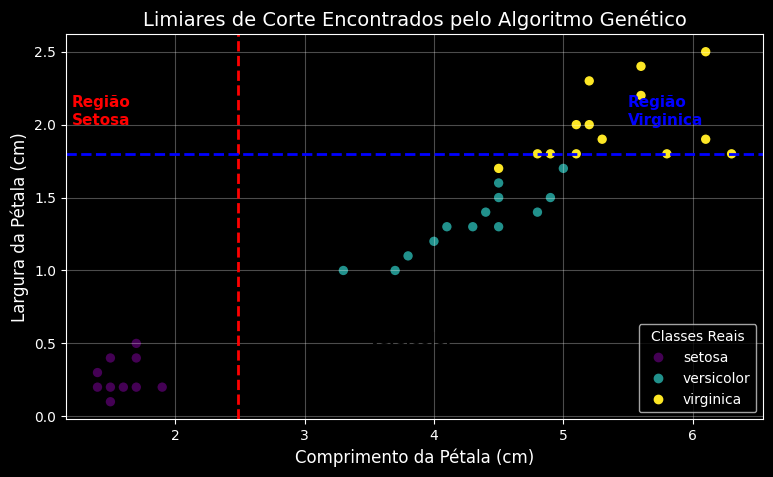

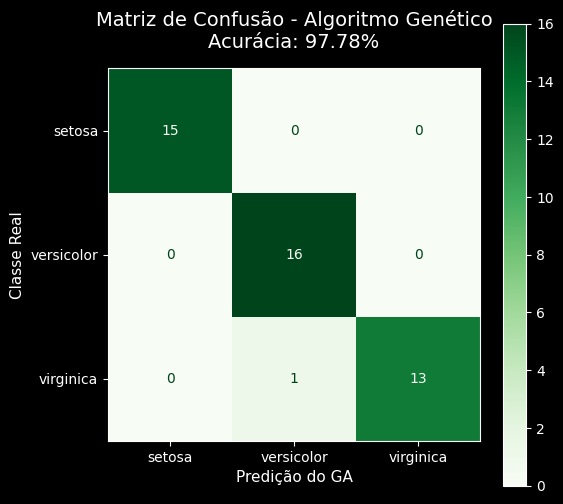

In [26]:
print(f"=== RESULTADOS DO ALGORITMO GENÉTICO ===")
print(f"Acurácia: {acc_ga * 100:.2f}%")
print(f"Limiar encontrado para Setosa (Comprimento da Pétala <): {limiar_setosa:.2f} cm")
print(f"Limiar encontrado para Virginica (Largura da Pétala >): {limiar_virginica:.2f} cm")
print("-" * 40)
print(f"Previsões (15 primeiras): {y_pred_ga[:15]}")
print(f"Gabarito Real:            {list(y_test[:15])}")

# ==========================================
# GRÁFICO 1: Fronteiras de Decisão (Scatter Plot)
# ==========================================
plt.figure(figsize=(9, 5))

# Plotando os pontos reais do conjunto de TESTE
# X_test[:, 2] é o Comprimento da Pétala, X_test[:, 3] é a Largura
scatter = plt.scatter(X_test[:, 2], X_test[:, 3], c=y_test, cmap='viridis', edgecolor='k', s=60)

# Desenhando as linhas (limiares) que o GA encontrou
plt.axvline(x=limiar_setosa, color='red', linestyle='--', linewidth=2, label=f'Corte Setosa ({limiar_setosa:.2f})')
plt.axhline(y=limiar_virginica, color='blue', linestyle='--', linewidth=2, label=f'Corte Virginica ({limiar_virginica:.2f})')

# Adicionando legendas das classes
handles, _ = scatter.legend_elements()
plt.legend(handles, iris.target_names, loc="lower right", title="Classes Reais")

# Textos auxiliares para explicar as regiões do gráfico
plt.text(1.2, 2.0, 'Região\nSetosa', fontsize=11, color='red', fontweight='bold')
plt.text(3.5, 0.5, 'Região\nVersicolor', fontsize=11, color='black', fontweight='bold')
plt.text(5.5, 2.0, 'Região\nVirginica', fontsize=11, color='blue', fontweight='bold')

plt.title('Limiares de Corte Encontrados pelo Algoritmo Genético', fontsize=14)
plt.xlabel('Comprimento da Pétala (cm)', fontsize=12)
plt.ylabel('Largura da Pétala (cm)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

# ==========================================
# GRÁFICO 2: Matriz de Confusão
# ==========================================
cm = confusion_matrix(y_test, y_pred_ga)
nomes_classes = iris.target_names

fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=nomes_classes)
disp.plot(cmap='Greens', ax=ax, values_format='d') # Usando verde para diferenciar do Fuzzy

plt.title(f'Matriz de Confusão - Algoritmo Genético\nAcurácia: {acc_ga * 100:.2f}%', fontsize=14, pad=15)
plt.xlabel('Predição do GA', fontsize=11)
plt.ylabel('Classe Real', fontsize=11)
plt.show()